# Seatbelt / Non‑Seatbelt CNN Training

In [1]:

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt


c:\Users\Night-Fury\AppData\Local\Programs\Python\Python312\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.0 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\Night-Fury\AppData\Local\Programs\Python\Python312\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.0 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\Night-Fury\AppData\Local\Programs\Python\Python312\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.0 at tensorfl

In [2]:

train_dir = r"E:\Comsats\6th Semester\DL\hamza\Data\train"
test_dir  = r"E:\Comsats\6th Semester\DL\hamza\Data\test"
model_path = r"E:\Comsats\6th Semester\DL\hamza\Models\cnn_model.h5"


In [3]:

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20


In [4]:

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_data = test_gen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)


Found 7017 images belonging to 2 classes.
Found 1600 images belonging to 2 classes.


In [5]:
train_data.class_indices

{'Seat_Belt': 0, 'WithoutSeat_Belt': 1}

In [6]:

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(2, activation='softmax')
])


c:\Users\Night-Fury\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,218 (42.61 MB)

 Trainable params: 11,169,218 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)


In [9]:

history = model.fit(
    train_data,
    epochs=EPOCHS,
    validation_data=test_data,
    callbacks=[early_stop]
)


c:\Users\Night-Fury\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 182s 822ms/step - accuracy: 0.9621 - loss: 0.0971 - val_accuracy: 0.9894 - val_loss: 0.0328
Epoch 2/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 98s 444ms/step - accuracy: 0.9954 - loss: 0.0129 - val_accuracy: 0.9925 - val_loss: 0.0579
Epoch 3/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 97s 439ms/step - accuracy: 0.9999 - loss: 8.5246e-04 - val_accuracy: 0.9919 - val_loss: 0.1187
Epoch 4/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 106s 480ms/step - accuracy: 0.9857 - loss: 0.0447 - val_accuracy: 0.9944 - val_loss: 0.0205
Epoch 5/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 106s 481ms/step - accuracy: 0.9986 - loss: 0.0035 - val_accuracy: 0.9956 - val_loss: 0.0157
Epoch 6/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 94s 427ms/step - accuracy: 1.0000 - loss: 3.8364e-04 - val_accuracy: 0.9956 - val_loss: 0.0187
Epoch 7/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 83s 377ms/step - accuracy: 0.9967 - loss: 0.0137 - val_accuracy: 0.9925 - val_loss: 0.0240
Epoch 8/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 103s 469ms/step - accuracy: 0.99

In [10]:

model.save(model_path)
print("Model saved at:", model_path)


Model saved at: E:\Comsats\6th Semester\DL\hamza\Models\cnn_model.h5


In [11]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np


In [12]:
# Predict probabilities
y_pred_prob = model.predict(test_data)

# Convert probabilities to class labels
y_pred = np.argmax(y_pred_prob, axis=1)

# True labels
y_true = test_data.classes


50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 141ms/step


In [13]:
class_names = list(test_data.class_indices.keys())
class_names


['Seat_Belt', 'WithoutSeat_Belt']

In [14]:
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))


Classification Report:

                  precision    recall  f1-score   support

       Seat_Belt       0.48      0.47      0.48       800
WithoutSeat_Belt       0.48      0.48      0.48       800

        accuracy                           0.48      1600
       macro avg       0.48      0.48      0.48      1600
    weighted avg       0.48      0.48      0.48      1600



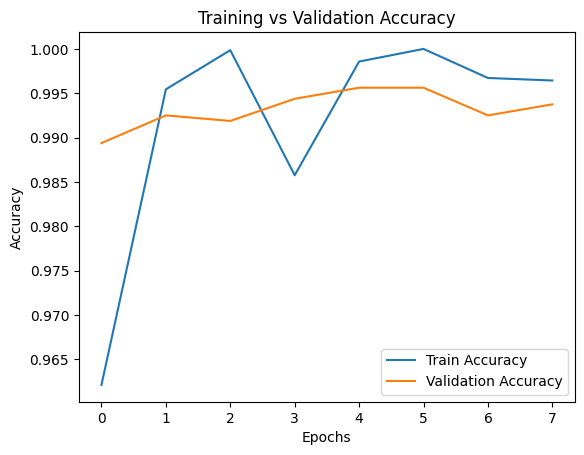

In [15]:

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.show()


# Gradio


In [16]:
import gradio as gr
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import json

# ==========================
# LOAD TRAINED MODEL
# ==========================
model = load_model(
    r"E:\Comsats\6th Semester\DL\hamza\Models\cnn_model.h5"
)

# ==========================
# LOAD CLASS INDICES
# (SAME ORDER AS TRAINING)
# ==========================
# IMPORTANT: copy this dictionary EXACTLY from your notebook output
# Example from train_data.class_indices
class_indices = {
    "Seatbelt": 0,
    "NoSeatbelt": 1
}

# Reverse mapping: index → class name
class_labels = {v: k for k, v in class_indices.items()}

# ==========================
# PREDICTION FUNCTION
# ==========================
def predict_seatbelt(img):
    # Resize & preprocess
    img = img.resize((224, 224))
    img = np.array(img) / 255.0
    img = np.expand_dims(img, axis=0)

    # Predict
    preds = model.predict(img)
    class_id = np.argmax(preds)

    return class_labels[class_id]

# ==========================
# GRADIO INTERFACE
# ==========================
interface = gr.Interface(
    fn=predict_seatbelt,
    inputs=gr.Image(type="pil", label="Upload Driver Image"),
    outputs=gr.Label(label="Prediction"),
    title="Seatbelt / Non-Seatbelt Detection",
    description="CNN-based Seatbelt Detection (Corrected Class Mapping)"
)

interface.launch()


c:\Users\Night-Fury\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


In [17]:
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report:

                  precision    recall  f1-score   support

       Seat_Belt       0.48      0.47      0.48       800
WithoutSeat_Belt       0.48      0.48      0.48       800

        accuracy                           0.48      1600
       macro avg       0.48      0.48      0.48      1600
    weighted avg       0.48      0.48      0.48      1600



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
